## Knižnice

In [1]:
## 1. Základná manipulácia s dátami a numerika
import pandas as pd
import numpy as np
import os
import wandb
from kaggle_secrets import UserSecretsClient

# 2. Vizualizácia dát
import matplotlib.pyplot as plt  
import seaborn as sns  
import tensorflow as tf

import cv2

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Pozrieme sa, v akom tvare su nase data

In [ ]:
DATA_DIR = '/kaggle/input/american-sign-language/ASL_Dataset'
# Pozrime sa, co je vnutri
print(os.listdir(DATA_DIR))  

In [5]:
TRAIN_DIR = os.path.join(DATA_DIR, 'Train')
TEST_DIR = os.path.join(DATA_DIR, 'Test')

# Pozrime sa, ake su tam triedy (pismena)
CLASSES = os.listdir(TRAIN_DIR)
CLASSES.sort()

## Načítanie dát

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

total_train_images = sum(len(files) for _, _, files in os.walk(TRAIN_DIR))
total_test_images  = sum(len(files) for _, _, files in os.walk(TEST_DIR))

print("Počty obrázkov načítané zo systému:")
print(f"  • Tréningový priečinok (pred splitom): {total_train_images}")
print(f"  • Testovací priečinok: {total_test_images}")

# --- Dataset SPLIT ---
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical',
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical',
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical',
    shuffle=False
)

# --- Presné počty v jednotlivých datasetoch ---
train_count = 0
for batch, _ in train_data:
    train_count += batch.shape[0]

val_count = 0
for batch, _ in val_data:
    val_count += batch.shape[0]

test_count = 0
for batch, _ in test_data:
    test_count += batch.shape[0]

# --- Výpis ---
print("\nRozdelenie datasetu:")
print(f"  • Tréningová množina:  {train_count} obrázkov  ({train_count / total_train_images * 100:.2f} %)")
print(f"  • Validačná množina:   {val_count} obrázkov ({val_count / total_train_images * 100:.2f} %)")
print(f"  • Testovacia množina:  {test_count} obrázkov")


Počty obrázkov načítané zo systému:
  • Tréningový priečinok (pred splitom): 165670
  • Testovací priečinok: 112
Found 165670 files belonging to 28 classes.
Using 132536 files for training.


2025-11-28 11:07:40.954422: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 165670 files belonging to 28 classes.
Using 33134 files for validation.
Found 112 files belonging to 28 classes.

Rozdelenie datasetu:
  • Tréningová množina:  132536 obrázkov  (80.00 %)
  • Validačná množina:   33134 obrázkov (20.00 %)
  • Testovacia množina:  112 obrázkov


celkom cool vec, ktoru mozme dat potom pred trenovanie modelu a malo by to to trenovanie zrychlit

In [11]:
#AUTOTUNE = tf.data.AUTOTUNE
#train_data = train_data.prefetch(AUTOTUNE)
#val_data = val_data.prefetch(AUTOTUNE)
#test_data = test_data.prefetch(AUTOTUNE)

## EDA

1. Zobrazit kolko mame dat
2. Zobrazit ako vyzeraju
3. Zobrazit ake su velke
4. Zobrazit aky maju pocet kanalov

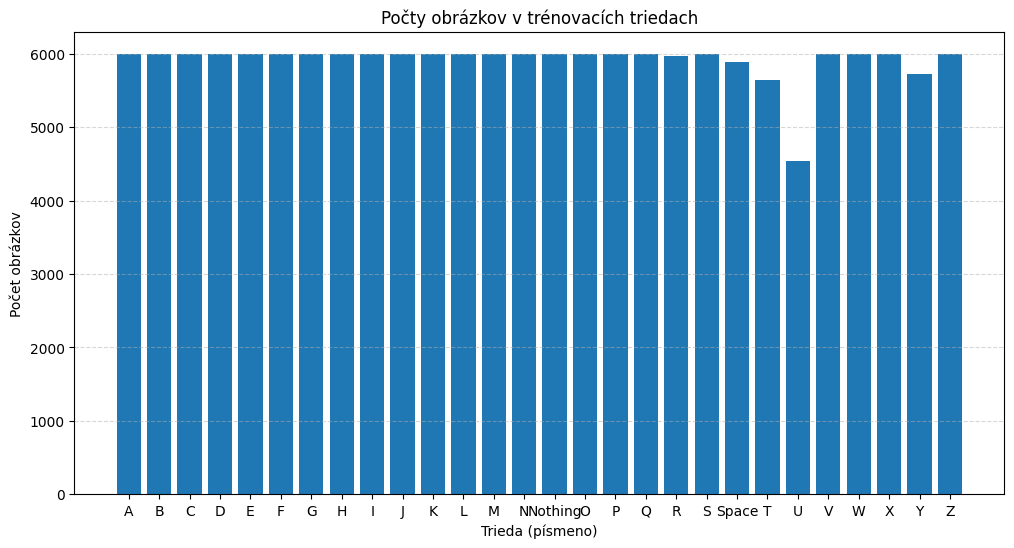

In [12]:
counts = {}
for pismeno in CLASSES:
    path = os.path.join(TRAIN_DIR, pismeno)
    counts[pismeno] = len(os.listdir(path))

# Vykreslenie
plt.figure(figsize=(12, 6))
plt.bar(counts.keys(), counts.values())
plt.title("Počty obrázkov v trénovacích triedach")
plt.xlabel("Trieda (písmeno)")
plt.ylabel("Počet obrázkov")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Zobrazíme si pár obrazkov nech vieme, s čím pracujeme.

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

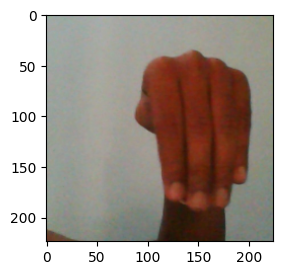

In [15]:
# Zoberieme si jednu varku (batch) z trenovacich dat
for images, labels in train_data.take(1):
    # images = varka 32 obrazkov (lebo BATCH_SIZE=32)
    # labels = varka 32 labelov

    plt.figure(figsize=(10, 10))
    for i in range(9): # Zobrazime prvych 9 obrazkov z varky
        ax = plt.subplot(3, 3, i + 1)

        # Obrazky su normalizovane (0-255), pre plt.imshow ich musime pretypovat
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')

        # Labely su 'categorical', takze musime najst index s najvyssou hodnotou
        label_index = np.argmax(labels[i])
        plt.title(f"Label: {train_data.class_names[label_index]}")
        plt.axis("off")

    plt.show()

Pozrieme sa na to, akú majú obrázky veľkosť

In [ ]:
from PIL import Image

def ziskaj_rozmery_obrazkov_fast(root_dir):
    sirky, vysky, kanaly = [], [], []

    for trieda in os.listdir(root_dir):
        cesta_triedy = os.path.join(root_dir, trieda)
        if not os.path.isdir(cesta_triedy):
            continue

        for subor in os.listdir(cesta_triedy):
            cesta_obr = os.path.join(cesta_triedy, subor)

            try:
                with Image.open(cesta_obr) as img:
                    w, h = img.size
                    c = len(img.getbands())   # napr. ("R","G","B") → 3

                    sirky.append(w)
                    vysky.append(h)
                    kanaly.append(c)

            except Exception as e:
                print("Chyba pri načítaní:", cesta_obr)

    return sirky, vysky, kanaly


In [ ]:
sirky, vysky, kanaly = ziskaj_rozmery_obrazkov(TRAIN_DIR)

print("Celkový počet načítaných obrázkov:", len(sirky))
print("Min šírka:", min(sirky), " | Max šírka:", max(sirky))
print("Min výška:", min(vysky), " | Max výška:", max(vysky))
print("Kanály (unikátne hodnoty):", set(kanaly))

plt.figure(figsize=(18, 5))

# Šírky
plt.subplot(1, 3, 1)
plt.hist(sirky, bins=20)
plt.title("Histogram šírok obrázkov")
plt.xlabel("Šírka (px)")
plt.ylabel("Počet obrázkov")
plt.grid(True, linestyle="--", alpha=0.4)

# Výšky
plt.subplot(1, 3, 2)
plt.hist(vysky, bins=20)
plt.title("Histogram výšok obrázkov")
plt.xlabel("Výška (px)")
plt.ylabel("Počet obrázkov")
plt.grid(True, linestyle="--", alpha=0.4)

# Kanály
plt.subplot(1, 3, 3)
plt.hist(kanaly, bins=5)
plt.title("Histogram počtu kanálov")
plt.xlabel("Počet kanálov")
plt.ylabel("Počet obrázkov")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

wandb

In [ ]:
wandb_key = UserSecretsClient().get_secret("wandb_api")
wandb.login(key=wandb_key)

# ResNet-50

### Prvé sme sa rozhodli urobiť Res-Net50. Prečo?? Prečo nie, pýtaš sa príliš veľa otázok...

(páči sa mi že má skip connections, je pomerne rýchly a fajn pre stredne veľké množstvo dát, ako máme my)

In [ ]:
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Aplikovanie preprocessingu cez .map()
train_ds = train_data.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(256).prefetch(buffer_size=2)

test_ds = test_data.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=2)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

NUM_CLASSES = 28

# 1. Stiahnutie predtrénovaného ResNet50 (bez hornej klasifikačnej vrstvy)
base_model = ResNet50(
    weights='imagenet',  # Použijeme váhy natrénované na ImageNet
    include_top=False,   # Odstránime poslednú vrstvu
    input_shape=(224, 224, 3)
)

# 2. Zmrazenie váh base modelu
base_model.trainable = False

# 3. Vytvorenie nového modelu
model = models.Sequential([
    # Augmentácia dát (náhodné preklopenie/otočenie pre lepšiu robustnosť)
    # layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 4. Kompilácia modelu
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import wandb


from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
wandb.init(project="ASL_ResNet", config={"model": "ResNet50", "epochs": 10})

callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True,
        verbose=1
    ),
    
    ModelCheckpoint(
        "best_asl_resnet.keras", 
        save_best_only=True, 
        monitor='val_loss',
        verbose=1
    ),
    WandbMetricsLogger()
]


history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=callbacks
)
wandb.finish()

Do budúcnosti premýľame že výskúšame aj tieto modeli

EfficientNet, MobileNetV3